### Setting

In [1]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import torch
import imageio
import numpy as np
import pandas as pd
from PIL import Image
from typing import Dict
import pyarrow.parquet as pq

from hex.model.tools import read_mode_config
from hex.model.framework.base_framework import baseframework

/media/bsh/miniconda3/envs/hex/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Data Visualization

In [2]:
path = "/media/bsh/data/hex_data/cola_0530/data/chunk-000/episode_000000.parquet"
table = pq.read_table(path)
data = {
    name: table[name].to_pylist()
    for name in table.column_names
}
df = pd.DataFrame(data)
print(df["action.motion_token"][80])
print(df["action.hand_binary"][80])
print(df["observation.state"][0])

[-0.0625, 0.0625, -0.125, -0.25, -0.3125, 0.0, 0.0, 0.1875, 0.0, 0.125, 0.0625, 0.0625, -0.125, -0.1875, -0.125, 0.0, 0.0625, -0.125, 0.0, -0.125, 0.0, -0.375, -0.125, -0.1875, -0.0625, 0.3125, 0.0625, 0.0625, 0.125, 0.125, 0.0625, -0.125, -0.1875, 0.125, -0.125, 0.125, 0.0625, -0.0625, 0.0625, 0.0625, 0.0625, 0.0625, 0.0625, -0.0625, -0.0625, -0.0625, 0.0625, -0.125, 0.1875, 0.0, 0.25, 0.1875, 0.125, -0.1875, -0.125, 0.125, 0.3125, -0.125, 0.0, 0.125, -0.1875, 0.0625, 0.3125, -0.0625]
[0.0, 0.0]
[0.13755546510219574, 0.0471869520843029, 0.04525121673941612, 0.14965686202049255, -0.27310633659362793, -0.020097186788916588, -0.08929472416639328, 0.008948220871388912, -0.18107181787490845, 0.1781122088432312, -0.05577615648508072, -0.011414664797484875, -0.05222839489579201, -0.027869220823049545, -0.0016987142153084278, -0.00959936436265707, 0.1266373097896576, 0.019174760207533836, -0.2226908802986145, -0.5420105457305908, 0.28156936168670654, 0.26481541991233826, 1.0, 1.0, 1.0, 0.0, 1

In [3]:
print(np.array(df["observation.state"][0]).shape)
print(np.array(df["observation.projected_gravity"][0]).shape)

(43,)
(3,)


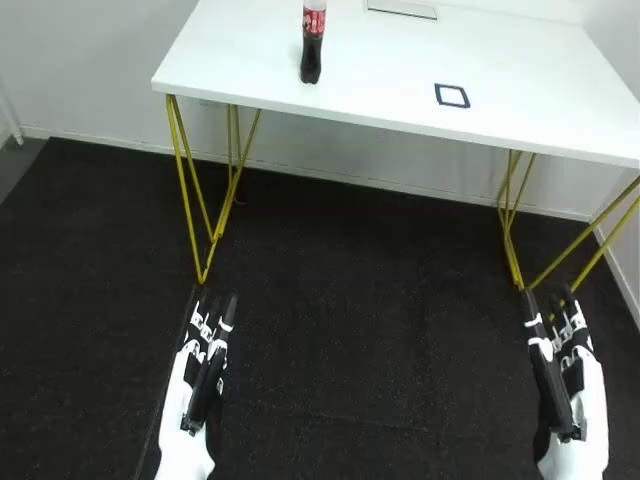

RGB
(480, 640, 3)
uint8


In [4]:
video_path = "/media/bsh/data/hex_data/cola_0530/videos/chunk-000/observation.images.ego_view/episode_000000.mp4"

reader = imageio.get_reader(video_path)
frame = reader.get_data(0)   # first frame
reader.close()

pil_img = Image.fromarray(frame)    # rgb
pil_img.show()
print(pil_img.mode)

arr = np.array(pil_img)
print(arr.shape)      # (H, W, 3)
print(arr.dtype)      # uint8

### Load and Evaluate Model

In [5]:
model_path = '/media/bsh/code/HEX/pretrained_models/hex/g1_sonic_real_world_pick_cola_2B/hex_ac100_30k_8gpu_state_query_history0/checkpoints/steps_30000_pytorch_model.pt'
infer_model = baseframework.from_pretrained(model_path)
infer_model = infer_model.to(torch.bfloat16)
infer_model = infer_model.to("cuda").eval()

instruction = ["Walk forward, grab the cola and throw into the trash bin"]

06/07 [19:04:42] INFO     | >> [*] Loading from local checkpoint path                            ]8;id=15478886;file:///media/bsh/code/HEX/hex/model/framework/share_tools.py\share_tools.py]8;;\:]8;id=15478887;file:///media/bsh/code/HEX/hex/model/framework/share_tools.py#246\246]8;;\
                          `/media/bsh/code/HEX/pretrained_models/hex/g1_sonic_real_world_pick_co                   
                          la_2B/hex_ac100_30k_8gpu_state_query_history0/checkpoints/steps_30000_                   
                          pytorch_model.pt`                                                                        

[EmbodimentRegistry] Saved registry to pretrained_models/hex/g1_sonic_real_world_pick_cola_2B/hex_ac100_30k_8gpu_state_query_history0/embodiment_registry.json
Total number of DiT parameters:  122441736


In [6]:
class Normalizer:
    valid_modes = ["q99", "mean_std", "min_max", "binary"]

    def __init__(self, mode: str, statistics: dict):
        self.mode = mode
        self.statistics = statistics
        for key, value in self.statistics.items():
            self.statistics[key] = torch.tensor(value)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert isinstance(
            x, torch.Tensor
        ), f"Unexpected input type: {type(x)}. Expected type: {torch.Tensor}"

        # Normalize the tensor
        if self.mode == "q99":
            # Range of q99 is [-1, 1]
            q01 = self.statistics["q01"].to(x.dtype)
            q99 = self.statistics["q99"].to(x.dtype)

            # In the case of q01 == q99, the normalization will be undefined
            # So we set the normalized values to the original values
            mask = q01 != q99
            normalized = torch.zeros_like(x)

            # Normalize the values where q01 != q99
            # Formula: 2 * (x - q01) / (q99 - q01) - 1
            normalized[..., mask] = (x[..., mask] - q01[..., mask]) / (
                q99[..., mask] - q01[..., mask]
            )
            normalized[..., mask] = 2 * normalized[..., mask] - 1

            # Set the normalized values to the original values where q01 == q99
            normalized[..., ~mask] = x[..., ~mask].to(x.dtype)

            # Clip the normalized values to be between -1 and 1
            normalized = torch.clamp(normalized, -1, 1)

        elif self.mode == "mean_std":
            # Range of mean_std is not fixed, but can be positive or negative
            mean = self.statistics["mean"].to(x.dtype)
            std = self.statistics["std"].to(x.dtype)

            # In the case of std == 0, the normalization will be undefined
            # So we set the normalized values to the original values
            mask = std != 0
            normalized = torch.zeros_like(x)

            # Normalize the values where std != 0
            # Formula: (x - mean) / std
            normalized[..., mask] = (x[..., mask] - mean[..., mask]) / std[..., mask]

            # Set the normalized values to the original values where std == 0
            normalized[..., ~mask] = x[..., ~mask].to(x.dtype)

        elif self.mode == "min_max":
            # Range of min_max is [-1, 1]
            min = self.statistics["min"].to(x.dtype)
            max = self.statistics["max"].to(x.dtype)

            # In the case of min == max, the normalization will be undefined
            # So we set the normalized values to the original values
            mask = min != max
            normalized = torch.zeros_like(x)

            # Normalize the values where min != max
            # Formula: 2 * (x - min) / (max - min) - 1
            normalized[..., mask] = (x[..., mask] - min[..., mask]) / (
                max[..., mask] - min[..., mask]
            )
            normalized[..., mask] = 2 * normalized[..., mask] - 1

            # Set the normalized values to the original values where min == max
            # normalized[..., ~mask] = x[..., ~mask].to(x.dtype)
            # Set the normalized values to 0 where min == max
            normalized[..., ~mask] = 0

        elif self.mode == "scale":
            # Range of scale is [0, 1]
            min = self.statistics["min"].to(x.dtype)
            max = self.statistics["max"].to(x.dtype)
            abs_max = torch.max(torch.abs(min), torch.abs(max))
            mask = abs_max != 0
            normalized = torch.zeros_like(x)
            normalized[..., mask] = x[..., mask] / abs_max[..., mask]
            normalized[..., ~mask] = 0

        elif self.mode == "binary":
            # Range of binary is [0, 1]
            normalized = (x > 0.5).to(x.dtype)
        else:
            raise ValueError(f"Invalid normalization mode: {self.mode}")

        return normalized

    def inverse(self, x: torch.Tensor) -> torch.Tensor:
        assert isinstance(
            x, torch.Tensor
        ), f"Unexpected input type: {type(x)}. Expected type: {torch.Tensor}"
        if self.mode == "q99":
            q01 = self.statistics["q01"].to(x.dtype)
            q99 = self.statistics["q99"].to(x.dtype)
            return (x + 1) / 2 * (q99 - q01) + q01
        elif self.mode == "mean_std":
            mean = self.statistics["mean"].to(x.dtype)
            std = self.statistics["std"].to(x.dtype)
            return x * std + mean
        elif self.mode == "min_max":
            min = self.statistics["min"].to(x.dtype)
            max = self.statistics["max"].to(x.dtype)
            return (x + 1) / 2 * (max - min) + min
        elif self.mode == "binary":
            return (x > 0.5).to(x.dtype)
        else:
            raise ValueError(f"Invalid normalization mode: {self.mode}")

In [7]:
infer_model.norm_stats

{'unitree_g1_sonic': {'action': {'mean': [-0.013584529981017113,
    -0.13980450194615585,
    -0.15413113053028402,
    -0.13084247135199034,
    -0.1696312507757774,
    0.06746980949090078,
    -0.07719387744481747,
    0.07096719741821289,
    0.07786015134591323,
    -0.1846229468400662,
    0.06543800664635806,
    0.05173060211997766,
    -0.1102806879923894,
    -0.17889313170543084,
    -0.11638082105379839,
    -0.056550592757188364,
    0.05639857340317506,
    -0.058471862513285414,
    0.016807552068852462,
    0.05764062974888545,
    -0.1488919212267949,
    -0.24723400748693028,
    -0.03203587807141818,
    -0.10749398057277386,
    0.0706714394573982,
    0.008043429527718287,
    -0.009503470447200995,
    0.09156825336126181,
    0.13541380144082582,
    0.000720241608527991,
    0.1003613999256721,
    0.006512034433678939,
    -0.10963518401751152,
    0.0838085521872227,
    -0.05776897044135974,
    0.16945709173495954,
    -0.1497100706283863,
    -0.0870165910

In [8]:
norm_stats = infer_model.norm_stats['unitree_g1_sonic']
action_norm_stats = norm_stats["action"]
print('action: ', action_norm_stats)
state_norm_stats = norm_stats["state"]
print('state: ', state_norm_stats)

action:  {'mean': [-0.013584529981017113, -0.13980450194615585, -0.15413113053028402, -0.13084247135199034, -0.1696312507757774, 0.06746980949090078, -0.07719387744481747, 0.07096719741821289, 0.07786015134591323, -0.1846229468400662, 0.06543800664635806, 0.05173060211997766, -0.1102806879923894, -0.17889313170543084, -0.11638082105379839, -0.056550592757188364, 0.05639857340317506, -0.058471862513285414, 0.016807552068852462, 0.05764062974888545, -0.1488919212267949, -0.24723400748693028, -0.03203587807141818, -0.10749398057277386, 0.0706714394573982, 0.008043429527718287, -0.009503470447200995, 0.09156825336126181, 0.13541380144082582, 0.000720241608527991, 0.1003613999256721, 0.006512034433678939, -0.10963518401751152, 0.0838085521872227, -0.05776897044135974, 0.16945709173495954, -0.1497100706283863, -0.08701659108583744, 0.13242660806729245, -0.0185908110669026, -0.04240872252445954, 0.18203930442149824, 0.018770207579319294, -0.10695243970705914, 0.07604587937776859, -0.081538160

In [12]:
video_path = "/media/bsh/data/hex_data/cola_0530/videos/chunk-000/observation.images.ego_view/episode_000000.mp4"

step = 10
reader = imageio.get_reader(video_path)
frame = reader.get_data(step) 
reader.close()

pil_img = Image.fromarray(frame).resize((224, 224), Image.Resampling.LANCZOS)    # rgb
batch_images = [[pil_img]]

normalizer_state = Normalizer('q99', state_norm_stats)
normalizer_action = Normalizer('q99', action_norm_stats)

# state = None
state = np.concatenate([df['observation.state'][step], df["observation.projected_gravity"][step]], axis=-1)[None, :]
state = torch.from_numpy(np.array(state))
state = normalizer_state.forward(state).unsqueeze(0)

tags = ['unitree_g1_sonic']

infer_model.reset()
action_pred: np.ndarray = infer_model.predict_action(batch_images, instruction, state, tags)['normalized_actions'][0][:, :66]

/tmp/ipykernel_3113093/2938462956.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.statistics[key] = torch.tensor(value)


In [13]:
unnorm_action_pred = normalizer_action.inverse(torch.tensor(action_pred))
unnorm_action_pred = unnorm_action_pred.numpy()
print('predict action:', unnorm_action_pred[0], unnorm_action_pred.shape)

actual_actions = np.concatenate([df['action.motion_token'][step], df['action.hand_binary'][step]], axis=-1)[None, :]
print('ground-truth action:', actual_actions[0], actual_actions.shape)

predict action: [-6.96816444e-02 -4.75296974e-02 -2.01000512e-01 -2.79801637e-01
 -1.75445959e-01  1.35271132e-01 -3.69889736e-02  2.05128193e-01
  7.59278089e-02 -1.11998081e-01  3.76932323e-02  5.40829003e-02
 -6.58716857e-02 -2.14702740e-01 -2.02462971e-01 -5.16726375e-02
  4.56961095e-02 -6.38846457e-02 -5.33425063e-02 -1.40606686e-01
 -1.17865443e-01 -3.76564205e-01 -1.39787942e-02 -2.60934830e-01
 -2.63524577e-02  5.95339835e-02  9.24556255e-02  5.35599589e-02
  1.88609421e-01  1.06512308e-01  2.08237767e-01 -1.46788210e-02
 -1.38669297e-01  1.87825143e-01 -1.44005090e-01  1.12378225e-01
 -1.71965629e-01 -1.14026055e-01  2.09766686e-01  8.56772661e-02
  1.02433562e-03  1.18485354e-01 -5.00392914e-03 -1.04442716e-01
  2.51534581e-02 -7.14431107e-02  2.36645341e-02 -1.68979838e-01
  9.29383934e-02 -1.99556351e-04  1.35858715e-01  3.96597981e-02
  1.84028685e-01 -1.87137321e-01 -1.12606138e-02  6.94788694e-02
  4.79690135e-02 -5.52207232e-02  6.22336417e-02  1.99056447e-01
  6.76727

In [ ]:
action_chunk = 40
if step + action_chunk > len(df['action.motion_token']):
    action_chunk = len(df['action.motion_token']) - step
motion = np.stack(
    df['action.motion_token'].iloc[step: step + action_chunk].to_numpy()
)
hand = np.stack(
    df['action.hand_binary'].iloc[step: step + action_chunk].to_numpy()
)
actual_actions = np.concatenate([motion, hand], axis=-1)[None, :]
mse = np.mean((unnorm_action_pred[0:action_chunk] - actual_actions) ** 2)
print('mse score: ', mse)

mse score:  0.000334784448480431
